In [1]:
from tqdm import tqdm

import pandas as pd

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from transformers import BertForSequenceClassification, BertTokenizer

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("smile-annotations-final.csv", header=None, names=["id", "text", "class"], index_col=0)

In [3]:
df["class"].unique()

array(['nocode', 'happy', 'not-relevant', 'angry', 'disgust|angry',
       'disgust', 'happy|surprise', 'sad', 'surprise', 'happy|sad',
       'sad|disgust', 'sad|angry', 'sad|disgust|angry'], dtype=object)

In [4]:
df = df[df["class"].isin(["happy", "angry", "sad", "surprise", "disgust", "not-relevant"])]

In [5]:
df["class"].value_counts()

class
happy           1137
not-relevant     214
angry             57
surprise          35
sad               32
disgust            6
Name: count, dtype: int64

In [6]:
labels = df["class"].unique()
labels

array(['happy', 'not-relevant', 'angry', 'disgust', 'sad', 'surprise'],
      dtype=object)

In [7]:
label2id = {j:i for i, j in enumerate(labels)}
id2label = {j:i for i, j in label2id.items()}

In [8]:
df["label"] = df["class"].apply(lambda row: label2id[row])

In [9]:
df.head()

,text,class,label
id,,,
614484565059596288,Dorian Gray with Rainbow Scarf #LoveWins (from...,happy,0
614746522043973632,@SelectShowcase @Tate_StIves ... Replace with ...,happy,0
614877582664835073,@Sofabsports thank you for following me back. ...,happy,0
611932373039644672,@britishmuseum @TudorHistory What a beautiful ...,happy,0
611570404268883969,@NationalGallery @ThePoldarkian I have always ...,happy,0


In [10]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
type(tokenizer)

transformers.models.bert.tokenization_bert.BertTokenizer

In [11]:
encoded = tokenizer.batch_encode_plus(
    df["text"].values, 
    padding=True,
    truncation=True,
    return_tensors="pt"
)
X = [{"input_ids": ids, "attention_mask": mask} for ids, mask in zip(encoded["input_ids"], encoded["attention_mask"])]
Y = df["label"].values

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    stratify=Y
)
len(X_train), len(X_test), type(X_train), type(y_train)

(1184, 297, list, numpy.ndarray)

In [13]:
class Dataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

    def __len__(self):
        return len(self.X)

Dtr = Dataset(X_train, y_train)
Dts = Dataset(X_test, y_test)

In [14]:
def collate_fn(batch):
    X, y = zip(*batch)
    return X, F.one_hot(torch.tensor(y), num_classes=6).float() #{
    #     "input_ids": X["input_ids"],
    #     "attention_mask": X["attention_mask"],
    #     "labels": F.one_hot(torch.tensor(y), num_classes=6).float()
    # }

Dltr = DataLoader(Dtr, batch_size=16, shuffle=True, drop_last=True, collate_fn=collate_fn)
Dlts = DataLoader(Dtr, batch_size=16, shuffle=True, drop_last=False, collate_fn=collate_fn)

In [15]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", 
    num_labels=len(labels)
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

optimizer = torch.optim.AdamW(model.parameters())

In [ ]:
model.train()
lossi = []
eval_lossi = []
for epoch in tqdm(range(5), desc="Epochs"):
    epoch_lossi = []
    for x, y in tqdm(Dltr, desc="Batches", leave=False):
        out = model(
            input_ids=torch.stack([i["input_ids"] for i in x]).to(device),
            attention_mask=torch.stack([i["attention_mask"] for i in x]).to(device),
            labels=y.to(device)
        )
        
        loss = out.loss
        epoch_lossi.append(loss.data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    lossi.append(torch.tensor(epoch_lossi).mean())
    
    epoch_lossi = []
    for x, y in Dltr:
        out = model(
            input_ids=torch.stack([i["input_ids"] for i in x]).to(device),
            attention_mask=torch.stack([i["attention_mask"] for i in x]).to(device),
            labels=y.to(device)
        )
        loss = out.loss
        epoch_lossi.append(loss.data)

    eval_lossi.append(torch.tensor(epoch_lossi).mean())

Epochs: 100%|██████████| 5/5 [01:25<00:00, 17.05s/it]


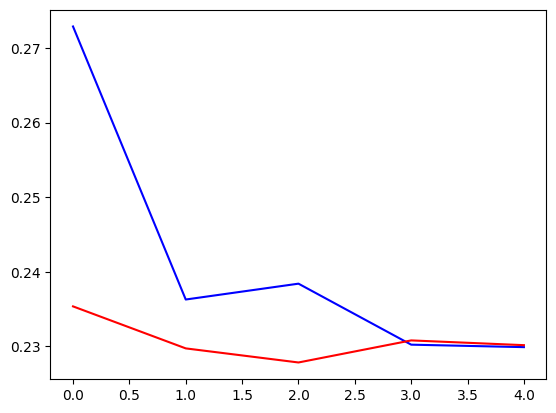

In [18]:
plt.plot(lossi, color='blue', label='training')
plt.plot(val_lossi, color='red', label='evaluation')
plt.show()

In [ ]:
print(lossi)
print(eval_lossi)

[tensor(0.2729), tensor(0.2363), tensor(0.2384), tensor(0.2302), tensor(0.2299)]
[tensor(0.2354), tensor(0.2297), tensor(0.2279), tensor(0.2308), tensor(0.2302)]


In [20]:
model.save_pretrained("fine_tuned_model")
tokenizer.save_pretrained("fine_tuned_model")

('fine_tuned_model\\tokenizer_config.json',
 'fine_tuned_model\\special_tokens_map.json',
 'fine_tuned_model\\vocab.txt',
 'fine_tuned_model\\added_tokens.json')

In [21]:
from huggingface_hub import notebook_login
notebook_login()

In [22]:
model.push_to_hub("mardonbekhazratov/bert-base-uncased-fine-tuned")
tokenizer.push_to_hub("mardonbekhazratov/bert-base-uncased-fine-tuned")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/mardonbekhazratov/bert-base-uncased-fine-tuned/commit/133f5e39d92bbf20c3413ef340d56db3c4db1b9a', commit_message='Upload tokenizer', commit_description='', oid='133f5e39d92bbf20c3413ef340d56db3c4db1b9a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mardonbekhazratov/bert-base-uncased-fine-tuned', endpoint='https://huggingface.co', repo_type='model', repo_id='mardonbekhazratov/bert-base-uncased-fine-tuned'), pr_revision=None, pr_num=None)